In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import flystar


import pickle as pickle
import pdb

from scipy.spatial import cKDTree as KDT
from matplotlib.patches import Rectangle
from numpy.polynomial.polynomial import polyfit
from scipy.stats import norm, tstd
from astropy.table import * 
from astropy.modeling import models, fitting
from flystar import match, transforms, plots, align, starlists
from flystar.starlists import StarList
from flystar.startables import StarTable
from astropy.table import Table, Column, vstack
from scipy.stats import gaussian_kde, kde

In [465]:
# Reading in matched GC star catalog
fits ='catalogs/dr2/jwst_init_NRCB.fits'
catalog = Table.read(fits, format='fits')
catalog.columns

csv = 'rc-magnitudes.csv'
df = pd.read_csv(csv)

In [470]:
def get_csv_matches(filt1, region1, filt2, region2):
    # Define a base column name for each filter
  # For NRCB1, this will be 'F115W', 'F212N', etc.
    
    # Map region to the correct suffix
    region_map = {
        'NRCB1': '',
        'NRCB2': '.1',
        'NRCB3': '.2',
        'NRCB4': '.3'
    }

    # Get the suffix based on the region
    suffix1 = region_map.get(region1, '')
    suffix2 = region_map.get(region2, '')

    # Construct the full column names
    column1 = f"{filt1}{suffix1}"  # e.g., 'F115W' or 'F115W.1'
    column2 = f"{filt2}{suffix2}"      # e.g., 'F212N' or 'F212N.1'

    # Get the arrays from the DataFrame
    array1 = df[column1]
    array2 = df[column2]

    return array1, array2

f115w, f212n = get_csv_matches('F115W', 'NRCB1', 'F212N', 'NRCB1')

f115w

0       21.287038
1       24.592848
2       23.556416
3       24.155071
4       24.149847
          ...    
5774          NaN
5775          NaN
5776          NaN
5777          NaN
5778          NaN
Name: F115W, Length: 5779, dtype: float64

In [473]:
def get_all_filts(t):
    """
    Helper function to get filts in a catalog, regardless of
    masking
    """
    nepochs = len(t['filt'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    filt_arr = []
    for ii in range(nepochs):
        filt_col = t['filt'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            filt_arr.append(t['filt'][good[0],ii])
        else:
            filt_arr.append(np.nan)
       

    filt_arr = np.array(filt_arr)
   
    return filt_arr

def get_all_dets(t): 
    """
    Helper function to get detectors in a catalog, regardless of
    masking
    """
    nepochs = len(t['det'][0])

    # Loop through each time entry and get year
    # from a non-masked source
    det_arr = []
    for ii in range(nepochs):
        det_col = t['det'][:,ii]

        good = np.where(t['x'][:,ii].mask == False)[0]
        if len(good) > 0:
            det_arr.append(t['det'][good[0],ii])
        else:
            det_arr.append(np.nan)

    det_arr = np.array(det_arr)
   
    return det_arr

def get_matches(t, filt1, det1, filt2, det2): 
    filt = get_all_filts(t)
    det = get_all_dets(t)

    idx1 = np.where( (filt == filt1) & (det == det1) ) 
    idx2 = np.where( (filt == filt2) & (det == det2) ) 

    filt_1 = t['m'][:,idx1]
    filt_2 = t['m'][:,idx2]

    filt_1me = t['me'][:,idx1]
    filt_2me = t['me'][:,idx2]
    
    good = np.where( (filt_1.mask == False) & (filt_2.mask == False) )
    m_filt1_match = filt_1[good]
    m_filt2_match = filt_2[good]
    me_filt1_match = filt_1me[good]
    me_filt2_match = filt_2me[good]

    return m_filt1_match, m_filt2_match, me_filt1_match, me_filt2_match

# All NRCBs between F212N and F115W
N1_f115w_vf212n, N1_f212n_vf115w, N1_f115w_vf212n_me, N1_f212n_vf115w_me = get_matches(catalog, 'F115W', 'NRCB1', 'F212N', 'NRCB1')


### Using the RC stars from a well-defined CMD to find the RC stars in a less-defined CMD
---

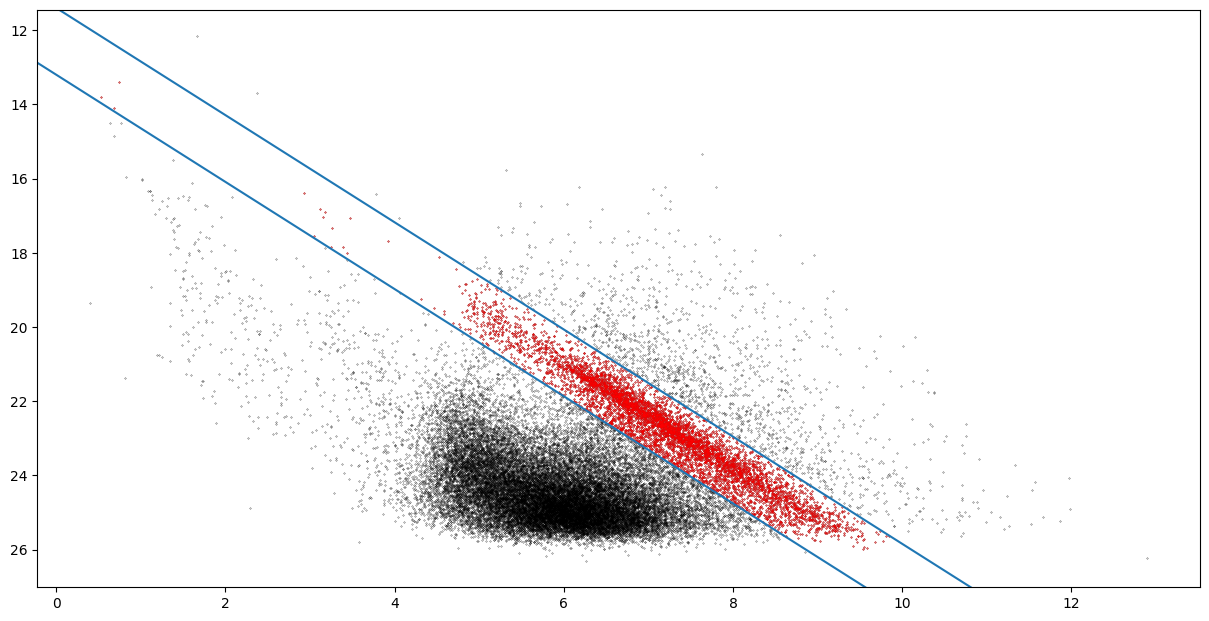

In [481]:
fig, axis = plt.subplots(1, 1, figsize = (15, 7.5))

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w)
y = N1_f115w_vf212n

plt.scatter(x, y, c='k', s = 0.05)
plt.gca().invert_yaxis()

xy1 = [(6.3, 20.5), (9, 24.4)]	
xy2 = [(6.3, 22.3), (9, 26.2)]

plt.axline(xy1[0], xy1[1])
plt.axline(xy2[0], xy2[1])

def slope(xy1,  xy2): 
    m = (xy2[1] - xy1[1])/(xy2[0] - xy1[0])
    b = xy1[1] - m * xy1[0]
    return m,b 

m1, b1 = slope(xy1[0], xy1[1])
m2, b2 = slope(xy2[0], xy2[1])
rc_idxs = np.where((y > (m1 * x + b1)) & (y < (m2 * x + b2)))

xrc = x[rc_idxs]
yrc = y[rc_idxs]

plt.scatter(xrc, yrc, c = 'r', s = 0.1)

full_indices = np.where(np.isin(catalog['m'], N1_f115w_vf212n[rc_idxs]))[0]

N1_F323_mag = catalog[full_indices]['m'][:, 9]
N1_F405_mag = catalog[full_indices]['m'][:, 8]
N1_F212_mag = catalog[full_indices]['m'][:, 4]
N1_F115_mag = catalog[full_indices]['m'][:, 0]

Text(0.5, 0.98, 'NRCB1')

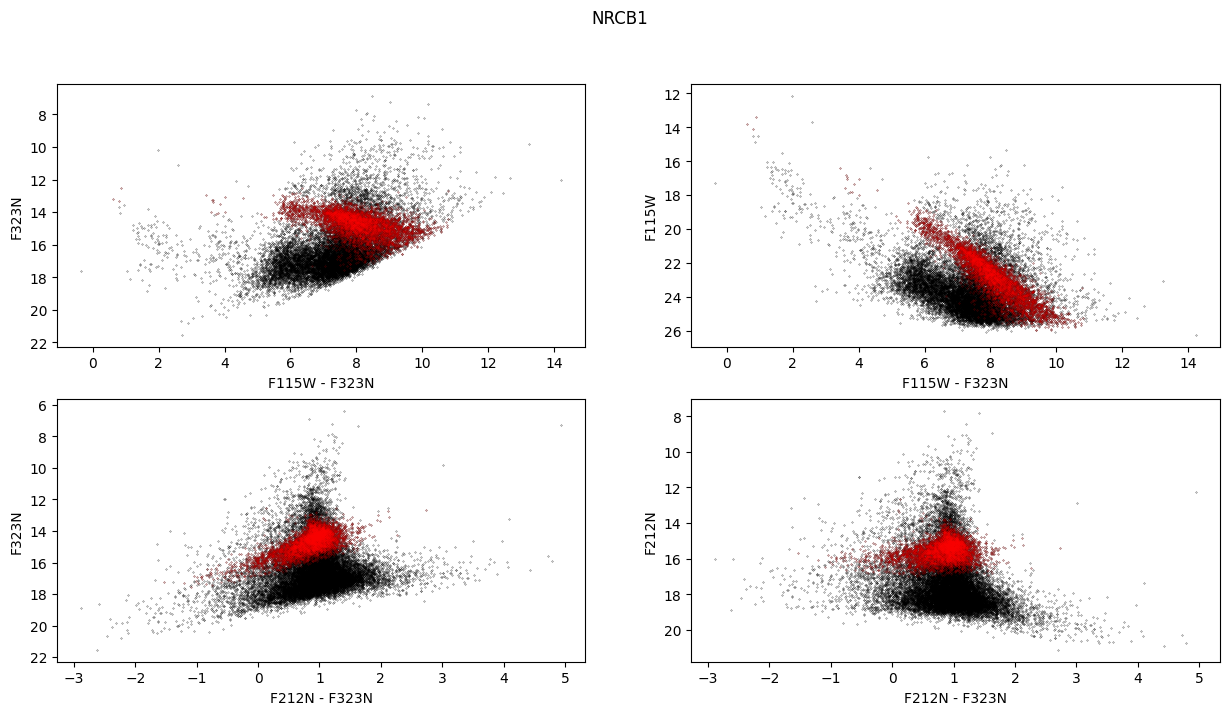

In [482]:
N1_f115w_v323n, N1_f323n_vf115w, N1_f115w_vf323n_me, N1_f323n_vf115w_me = get_matches(catalog, 'F115W', 'NRCB1', 'F323N', 'NRCB5')
N1_f212n_v323n, N1_f323n_vf212n, N1_f212n_vf323n_me, N1_f323n_vf212n_me = get_matches(catalog, 'F212N', 'NRCB1', 'F323N', 'NRCB5')

fig, axis = plt.subplots(2, 2, figsize = (15, 7.5))

axis[0,0].scatter(np.subtract(N1_f115w_v323n, N1_f323n_vf115w), N1_f323n_vf115w, c = 'k', s = 0.05)
axis[1,0].scatter(np.subtract(N1_f212n_v323n, N1_f323n_vf212n), N1_f323n_vf212n, c = 'k', s = 0.05)

axis[0,0].scatter(np.subtract(N1_F115_mag, N1_F323_mag), N1_F323_mag, c = 'r', s = 0.05, alpha = 0.5)
axis[1,0].scatter(np.subtract(N1_F212_mag, N1_F323_mag), N1_F323_mag, c = 'r', s = 0.05, alpha = 0.5)

axis[0,1].scatter(np.subtract(N1_f115w_v323n, N1_f323n_vf115w), N1_f115w_v323n, c = 'k', s = 0.05)
axis[1,1].scatter(np.subtract(N1_f212n_v323n, N1_f323n_vf212n), N1_f212n_v323n, c = 'k', s = 0.05)

axis[0,1].scatter(np.subtract(N1_F115_mag, N1_F323_mag), N1_F115_mag, c = 'r', s = 0.05, alpha = 0.5)
axis[1,1].scatter(np.subtract(N1_F212_mag, N1_F323_mag), N1_F212_mag, c = 'r', s = 0.05, alpha = 0.5)

for i in range(2):
    axis[0, i].set_xlabel('F115W - F323N')
    axis[1, i].set_xlabel('F212N - F323N')
    axis[i, 0].set_ylabel('F323N')
    for j in range(2): 
        axis[i,j].invert_yaxis()

axis[0, 1].set_ylabel('F115W')
axis[1, 1].set_ylabel('F212N')

plt.suptitle('NRCB1')


In [457]:
df = pd.DataFrame({
    'F115W': N1_F115_mag,
    'F212N': N1_F212_mag,
    'F323N': N1_F323_mag,
    'F405N': N1_F405_mag
}).to_csv('NRCB1-rcmags.csv')

### Rectangular Riemann Slope Determination
---

We define a rectanguar cutoff to extract the stars roughly in the area of the Red Clump Bar

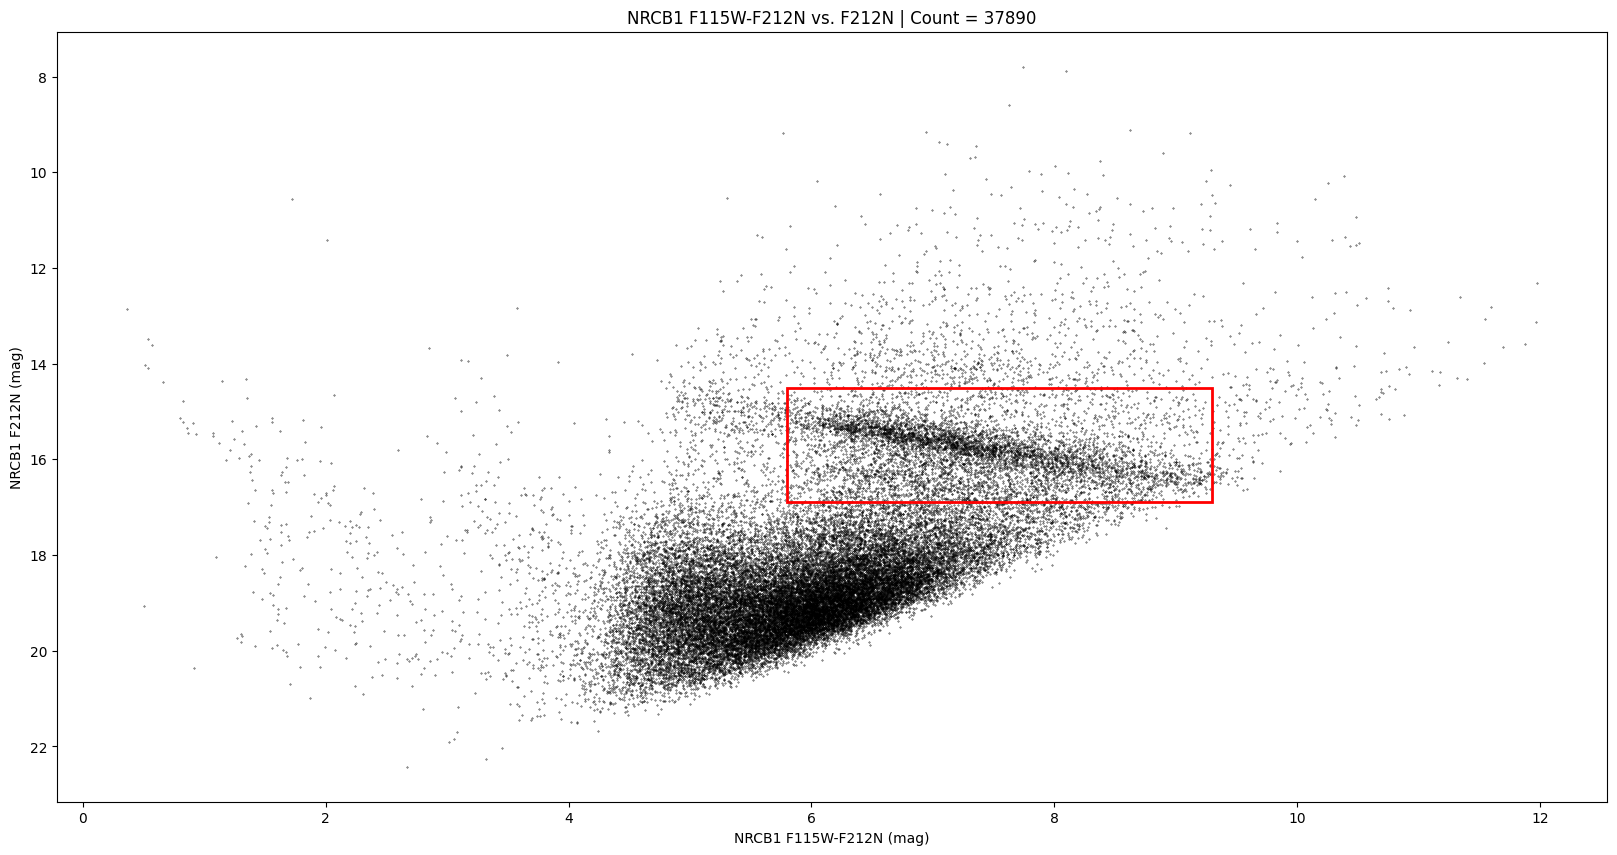

In [1158]:
fig, axis = plt.subplots(1,1, figsize = (20, 10))

x = np.subtract(N1_f115w_vf212n, N1_f212n_vf115w) # color
y = N1_f212n_vf115w

plt.scatter(x, y, c = 'k', s = 0.1)

plt.xlabel('NRCB1 F115W-F212N (mag)')
plt.ylabel('NRCB1 F212N (mag)')
plt.title(f'NRCB1 F115W-F212N vs. F212N | Count = {len(x)}')
plt.gca().invert_yaxis()

lower_x = 5.8
lower_y = 14.5
width = 3.5
height = 2.4

cutoff = Rectangle((lower_x, lower_y), width, height, facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1))
axis.add_patch(cutoff)

Now we extract the stars within the cutoff and find their mag-values from the original catalogs. Easy enough.

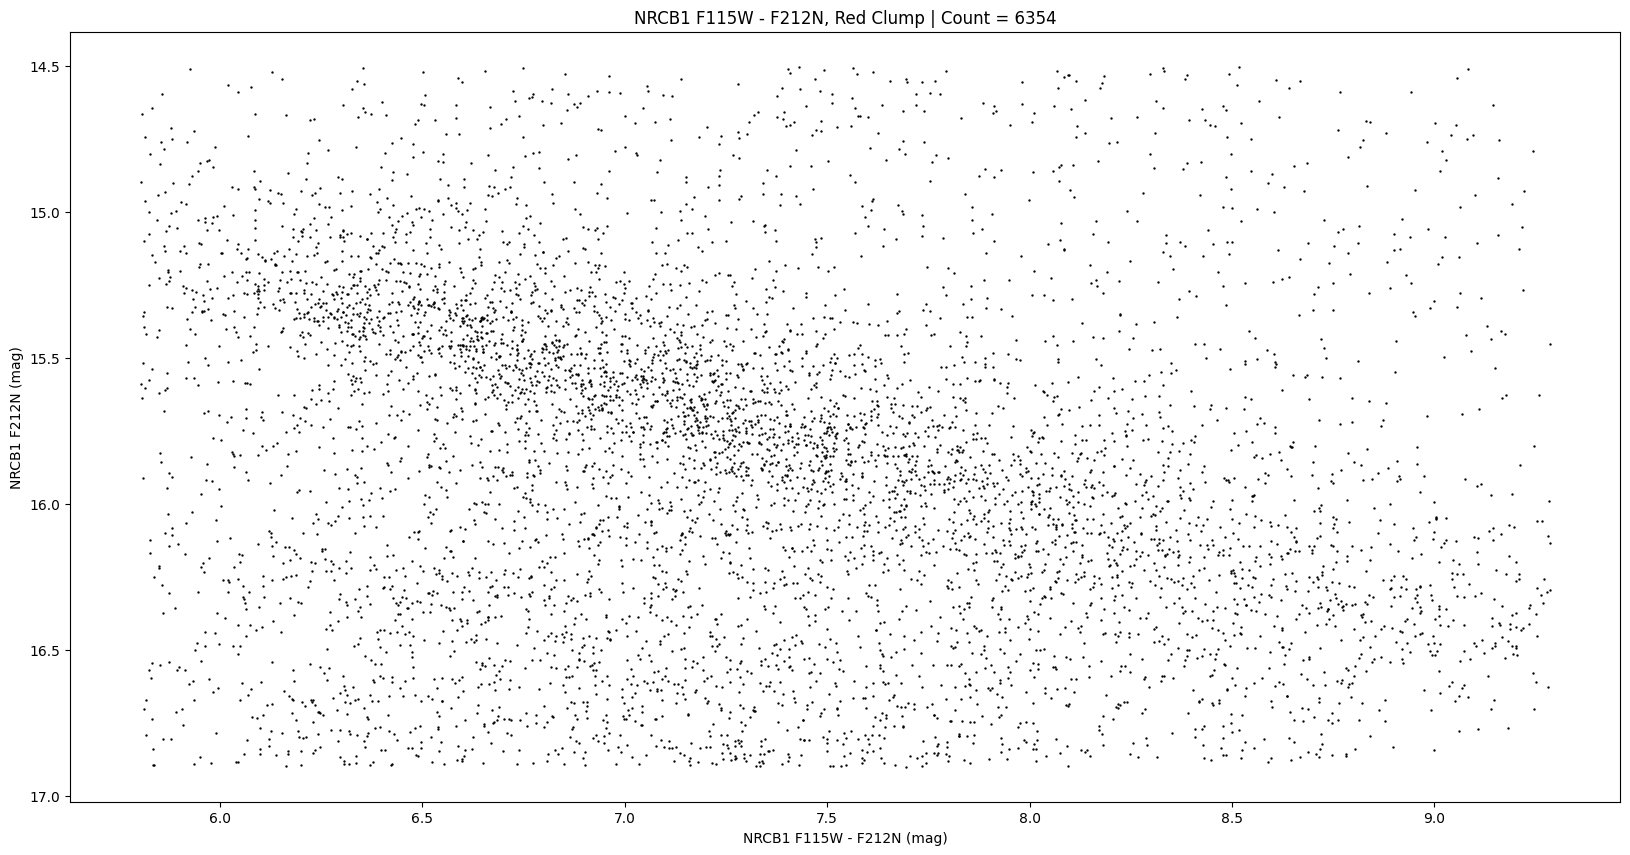

In [1159]:
idxs = np.where( (x >= lower_x) & (x < lower_x + width) & 
                 (y >= lower_y) & (y < lower_y + height)
               ) # indices of stars from original catalog within rectangular cutoff
x = x[idxs]
y = y[idxs]

fig, axis = plt.subplots(1, 1, figsize = (20, 10)) 

plt.scatter(x, y, c = 'k', s = 0.5)

plt.xlabel('NRCB1 F115W - F212N (mag)')
plt.ylabel('NRCB1 F212N (mag)')
plt.title(f'NRCB1 F115W - F212N, Red Clump | Count = {len(x)}')
plt.gca().invert_yaxis()

Our goal is now to write an algorithm to divide this Red Clump region into `n` subregions. We afterwards store the indices and mags of stars in each region in a `n x 2` dimensional array. 

In [1160]:
def divide_cutoff(n, lower_left, width, height):
    x, y = lower_left
    dx = width / n
    segment_height = height
    xbins = [] # stores the [leftest x, farthest x]...[ , ] of each subregion
    segments = [] # stores the matplotlib.patches.Rectangle objects for each subregion
                  # purely for plotting & visualization purposes
    
    for i in range(n):
        segments.append(Rectangle((x + i * dx, y), dx, segment_height, 
                                  facecolor = (1, 0, 0, 0), lw = 2, ec = (1, 0, 0, 1)
                                 )
                       )
        xbins.append([x + i * dx, x + i * dx + dx])
        
    return segments, xbins

def extract_stars(n, filt1, filt2, filt1name, filt2name, lower_left, width, height, show_plot, verbose): 
    # based on a filt1 - filt2 vs. filt2 CMD
    # xbins stores the [leftest x, farthest x]...[ , ] of each subregion
    # y_range is (lower_y, upper_y) range of cutoff
    # show_plot = Boolean, whether you want to see plot of subregions or not

    x = np.subtract(filt1, filt2)
    y = filt2

    lowerx, lower_y = lower_left
    upper_y = lower_y + height

    count = 0
    idxs = [] # (n x 2) array storing indices of stars in each subregion
    filt1_mag = [] # temporarily stores mag values of an individual subregion
    filt2_mag = [] # for plotting purposes

    segments, xbins = divide_cutoff(n, lower_left, width, height)

    for i in range(len(xbins)): 
        good = np.where((x >= xbins[i][0]) & (x < xbins[i][1]) & 
                       (y >= lower_y) & (y <= upper_y)) # extract indices of stars within each subregion
        
        idxs.append([good])
        filt1_mag.append([filt1[good]])
        filt2_mag.append([filt2[good]])
        
    if show_plot:
        colors = plt.cm.jet(np.linspace(0,1,len(filt1_mag))) # iterate through different colors
        fig, axis = plt.subplots(1, 1, figsize = (20, 10))
        
        for i in range(len(filt1_mag)): 
            plt.scatter(np.subtract(filt1_mag[i], filt2_mag[i]), filt2_mag[i], color = colors[i], s = 0.5)
            count += len(filt1_mag[i][0])

        plt.xlabel(f' {filt1name} - {filt2name} (mag)')
        plt.ylabel(f' {filt2name} (mag)')
        plt.title(f' {filt1name} - {filt2name} vs. {filt2name} | Count = {count} (mag)')
        plt.gca().invert_yaxis()

    # storing filt1 and filt2 magnitudes in DataFrame object for cleanliness
    # each row corresponds to each subregion left to right
    df1 = pd.DataFrame({f'{filt1name}': filt1_mag})
    df2 = pd.DataFrame({f'{filt2name}': filt2_mag})
    df = pd.concat([df1, df2], axis = 1)

    # shedding useless indices
    for i in range(len(df)): 
        df[filt1name][i] = df[filt1name][i][0]
        df[filt2name][i] = df[filt2name][i][0]

    if verbose: 
        display(df)

    return df, idxs

,NRCB1 F115W,NRCB1 F212N
0,"[21.373252923586055, 22.73159500360909, 20.788...","[15.456216617916951, 16.893641692471043, 14.94..."
1,"[21.53281883753172, 21.419129464704845, 21.336...","[15.514215681823334, 15.36093573910684, 15.277..."
2,"[21.27243539472737, 22.945900310219578, 21.897...","[15.06902703902269, 16.63759170154966, 15.5197..."
3,"[22.560889476557776, 21.88452423445645, 22.050...","[16.046262984685214, 15.394294059551207, 15.58..."
4,"[22.344850986955528, 22.029598540745717, 22.31...","[15.643171453494002, 15.369283216798785, 15.62..."
5,"[22.601279292005422, 22.710060451324203, 21.96...","[15.699451367235365, 15.75451110232374, 15.059..."
6,"[23.00355898546021, 22.791179264623217, 23.111...","[15.8440272148673, 15.744339418824989, 16.0609..."
7,"[23.799809103105247, 23.030624821002366, 22.99...","[16.58771841615052, 15.717733498046877, 15.763..."
8,"[22.84175951099361, 22.325649877403244, 23.330...","[15.460739077929201, 14.938873321440052, 15.83..."
9,"[24.132010574566905, 23.917944669843834, 23.29...","[16.50062705467344, 16.316962367073838, 15.674..."


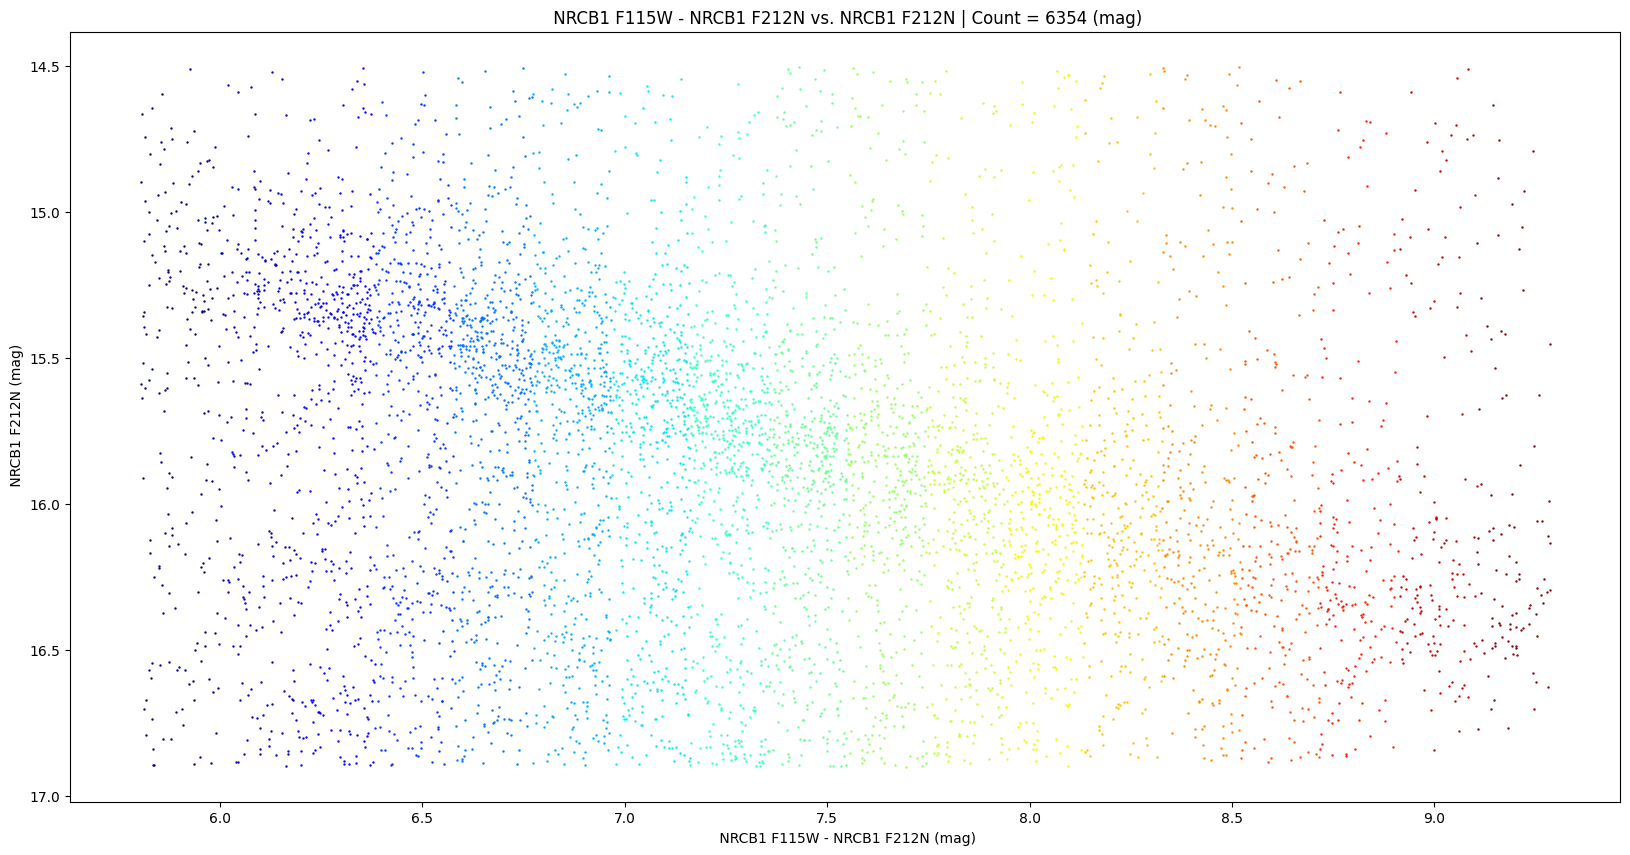

In [1505]:
starlist, idxs = extract_stars(n = 18, filt1 = N1_f115w_vf212n, filt2 = N1_f212n_vf115w, 
                     filt1name = 'NRCB1 F115W', filt2name = 'NRCB1 F212N', 
                     lower_left = (lower_x, lower_y), width = width, height=height, 
                     show_plot = True, verbose = True
                    )

### Time for Curve Fitting

- Generate histograms of each subregion
- Implement Preliminary `scipy.stats.norm` to determine rough std and mean
- Implement Scipy Compound `scipy.models.Gaussian1D` + `scipy.models.Linear1D`
- Iterate through varying amplitudes for the`Gaussian1D model` until the returned parameters make sense
- Iterate through generated histograms until the error on the mean $$ \varepsilon = \frac{\sigma}{\sqrt{N}}$$ is minimized
- Return the mean mag in color space and mean color value
- Plot mean mag vs. mean color -- the slope should be the same as the Red Clump Bar

In [1506]:
def optimize_bin(data, data_name, show_plot, verbose): 
    # find the number of bins in a histogram that minimizes the error_on_mean for given data
    
    mu, std = norm.fit(data) # preliminary mean and standard deviation from scipy.stats
    std = tstd(data, limits = (mu - 0.4, mu + 0.4))
    amplitude_works = False
    error_bin_amplitude_mean_std = []

    for i in range(8, 20): 
        
        amplitude_works = False
        j = 10
        count = 0
        
        while not amplitude_works:
            
            bin_heights, bin_borders = np.histogram(data, bins = i)
            bin_widths = np.diff(bin_borders)
            bin_centers = bin_borders[:-1] + bin_widths / 2
    
            t_gaussian = models.Gaussian1D(j, mu, std)
            t_linear = models.Linear1D(100, 100)
            t_compound = t_gaussian + t_linear
    
            filt_t = fitting.LevMarLSQFitter()
            t = filt_t(t_compound, bin_centers, bin_heights)

            if t.stddev_0.value > 0.1 and t.amplitude_0.value < 500 and t.amplitude_0.value > 0: # testing for if the fit works
                amplitude_works = True
                error_on_mean = t.stddev_0.value / math.sqrt(len(data))
                error_bin_amplitude_mean_std.append([error_on_mean, i, t.amplitude_0.value, t.mean_0.value, t.stddev_0.value])
            
            j += 20
            count += 1
            
            if count > 5: 
                amplitude_works = True
    
        if show_plot: 
            fig, axis = plt.subplots(1, 1, figsize = (20, 10))
            x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
            
            plt.bar(bin_centers, bin_heights, width=bin_widths, label='histogram')
            plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c='red', linestyle = 'dashed')
            plt.legend()

            plt.xlabel(f'{data_name}')
            plt.ylabel('Frequency')
            plt.title(f" Compound-Fitted Histogram | Mean = {t.mean_0.value.round(3)} | σ = {t.stddev_0.value.round(3)} | Error_on_mean = {(t.stddev_0.value / math.sqrt(len(data))).round(3)}")

    bins = []
    errors = [] 
    amplitudes = []
    means = []
    stds = []
    
    for i in range(len(error_bin_amplitude_mean_std)): # extracting error values into its own array
        bins.append(error_bin_amplitude_mean_std[i][1])
        errors.append(error_bin_amplitude_mean_std[i][0])
        amplitudes.append(error_bin_amplitude_mean_std[i][2])
        means.append(error_bin_amplitude_mean_std[i][3])
        stds.append(error_bin_amplitude_mean_std[i][4])
        
    bins = np.array(bins)
    errors = np.array(errors)
    amplitudes = np.array(amplitudes)
    means = np.array(means)
    stds = np.array(stds)
    
    while means[np.where(errors == errors.min())] > 17: 
        errors = np.delete(errors, np.where(errors == errors.min()))
        means = np.delete(means, np.where(errors == errors.min()))

    min_index = np.where((errors == errors.min())) # determining the # of bins with the smallest error_on_mean
    min_index = min_index[0][0]

    optimized_error = errors[min_index]
    optimized_bin_value = bins[min_index]
    optimized_amplitude = amplitudes[min_index]
    optimized_mean = means[min_index]
    optimized_std = stds[min_index]
    
    if verbose: 

        print(f"{data_name}")
        print(f" Bins |   Error   |  Amplitude  |    Mean    |    Std ")
        print(f"-------------------------------------------------------------")
        print(f" {optimized_bin_value}   |   { optimized_error.round(3):.3f}   |   {optimized_amplitude.round(4):.4f}   |   {optimized_mean.round(3):.3f}   |   {optimized_std.round(3):.3f}  ")
        print(f"")

    return optimized_bin_value, optimized_amplitude, optimized_mean, optimized_error, optimized_std

In [1507]:
def generate_hists(starlist, show_hist, verbose, path):

    ax = plt.figure(figsize = (10, 10)).add_subplot(projection = '3d')
    ax.view_init(elev=35, azim=-45, roll=0)
    colors = plt.cm.jet(np.linspace(0,1,len(starlist)))

    ax.set_xlabel(f"{starlist.columns[0]} - {starlist.columns[1]}")
    ax.set_ylabel(f"{starlist.columns[1]}")
    ax.set_zlabel("Frequency")
    ax.zaxis.labelpad=-0.01 # <- change the value here

    optimized_means = []
    optimized_mean_errors = []

    for i in range(len(starlist)): 
        
        ax.scatter(np.subtract(starlist[starlist.columns[0]][i], starlist[starlist.columns[1]][i]), 
                   starlist[starlist.columns[1]][i], 
                   zs = 0, zdir = 'z', label = 'CMD', 
                   color = colors[i], s = 0.3
                  )
        min_x = np.min(np.subtract(starlist[starlist.columns[0]][i], starlist[starlist.columns[1]][i]))

        # fitting 
        optimized_bin_value, optimized_amplitude, optimized_mean, optimized_error, optimized_std = optimize_bin(starlist[starlist.columns[1]][i], 
                                                                                                   starlist.columns[1], 
                                                                                                   show_plot = False, 
                                                                                                   verbose = verbose
        )

        optimized_means.append(optimized_mean)
        optimized_mean_errors.append(optimized_error)
        

        bin_heights, bin_borders = np.histogram(starlist[starlist.columns[1]][i], bins=optimized_bin_value)
        bin_widths = np.diff(bin_borders)
        bin_centers = bin_borders[:-1] + bin_widths / 2
        
        t_gaussian = models.Gaussian1D(optimized_amplitude, optimized_mean, optimized_std)
        t_linear = models.Linear1D(100, 100)
        t_compound = t_gaussian + t_linear
        
        fit_t = fitting.LevMarLSQFitter()
        t = fit_t(t_compound, bin_centers, bin_heights)
        
        x_interval_for_fit = np.linspace(bin_borders[0], bin_borders[-1], 10000)
        
        if show_hist: 
            plt.bar(bin_centers, bin_heights, width=bin_widths, label='histogram', zs = min_x, zdir = 'x', ec = 'k', facecolor = (0,0,0,0))
        
        plt.plot(x_interval_for_fit, t(x_interval_for_fit), label='fit', c=colors[i], zs = min_x, zdir = 'x')
        
        plt.savefig(f"{path}/{starlist.columns[1]}_optimized_with_{len(starlist)}_bins.png")
                
    return optimized_means, optimized_mean_errors

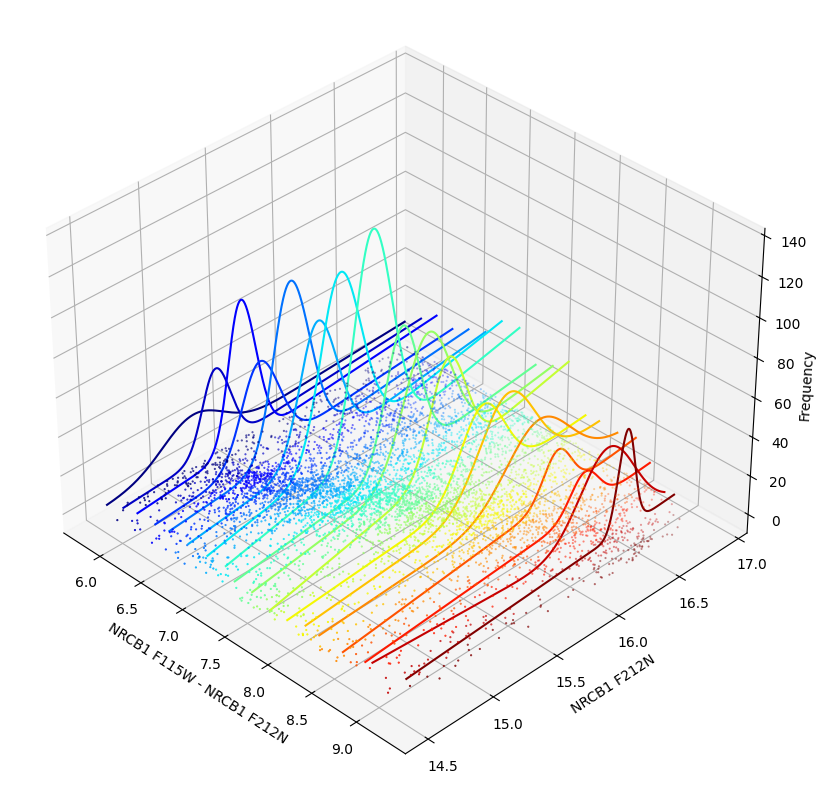

In [1508]:
optimized_means, optimized_mean_errors = generate_hists(starlist, show_hist = False, verbose = False, path = "/Users/devaldeliwala/research/work/rc_analysis_plots")

In [1513]:
N1_115_catalog = Table.read("catalogs/dr2/NRCB1_catalog115w.csv").to_pandas()
N1_212_catalog = Table.read("catalogs/dr2/NRCB1_catalog212n.csv").to_pandas()

In [1514]:
df, df2 = N1_115_catalog, N1_212_catalog

x1 = df['x']   # x centroid position of catalog1 stars
y1 = df['y']   # y centroid position of catalog1 stars 
m1 = df['m']   # vega magnitude of catalog1 stars
me1 = df['me'] # error in vega magnitude of catalog1 stars
x2 = df2['x']
y2 = df2['y']
m2 = df2['m']
me2 = df2['me']

In [1518]:
idxs1, idxs2, dr, dm = flystar.match.match(x1, y1, m1, x2, y2, m2, 
                                                  dr_tol = 0.5, dm_tol = 100, 
                                                  verbose = False)

In [1546]:
m1_error, m2_error = me1[idxs1], me2[idxs2]
m1_matched, m2_matched = m1[idxs1], m2[idxs2]

m1_matched = np.array(m1_matched)
m2_matched = np.array(m2_matched)

m_difference = np.subtract(m1_matched, m2_matched)

xy = np.vstack([m_difference, m2_matched])
z = gaussian_kde(xy)(xy)

In [1548]:
print(len(m1_matched))

29513
